# Time series forecasting with TTM-R3

This notebook demonstrates how to use TTM-R3 in a time series forecasting task using the forecasting pipeline.  

## Preparing the experiments

To get started, please follow the installation instructions from [here](https://github.com/ibm-granite/granite-tsfm/?tab=readme-ov-file#initial-setup).

Import the necessary dependencies

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import torch

from tsfm_public import TimeSeriesForecastingPipeline
from tsfm_public.toolkit.get_model import get_model
from tsfm_public.toolkit.time_series_preprocessor import create_timestamps, prepare_data_splits

## Main arguments to set
**context_length** refers to the length of the historical observation available to the model  
**prediction_length** refers to the forecast horizon 

In [2]:
MODEL_PATH = "ibm-research/ttm-r3"
TIMESTAMP_COLUMN = "date"
TARGET_COLUMNS = ["HUFL"]
CONTEXT_LENGTH = 2048
PREDICTION_LENGTH = 96
BATCH_SIZE = 64

In [3]:
DEVICE = "cuda" if torch.cuda.is_available() else ("mps" if torch.mps.is_available() else "cpu")

### Utility: Data loading

In [4]:
def load_ett_data(
    context_length=2048,
    prediction_length=96,
    timestamp_column="date",
    target_columns=["HUFL"],  # "HULL", "MUFL", "MULL", "LUFL", "LULL", "OT"],
    id_columns=[],  # mention the ids that uniquely identify a time-series.
):
    # prepare data splits according to the original example, but with revised context length
    split_config = {
        "train": [0, 8640],
        "valid": [8640, 11520],
        "test": [
            11520,
            14400,
        ],
    }
    dataset_path = "https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTh1.csv"
    data = pd.read_csv(
        dataset_path,
        parse_dates=[timestamp_column],
    )
    train_df, valid_df, test_df = prepare_data_splits(data, context_length=context_length, split_config=split_config)
    return train_df, valid_df, test_df

In [5]:
train_df, valid_df, test_df = load_ett_data(context_length=CONTEXT_LENGTH, prediction_length=PREDICTION_LENGTH)

## Simple forecast with TimeSeriesForecastingPipeline

### Utility: Model loading
Use the `get_model()` utility funciton to load the suitable TTM model

In [6]:
model = get_model(
    MODEL_PATH, context_length=CONTEXT_LENGTH, prediction_length=PREDICTION_LENGTH, freq="H", use_lite=False
)

INFO:p-529606:t-22446896296640:get_model.py:get_model:Loading model from: ibm-research/ttm-r3
INFO:p-529606:t-22446896296640:get_model.py:get_model:Model path type is 4
INFO:p-529606:t-22446896296640:get_model.py:get_model:Loading model from: ibm-granite/granite-timeseries-ttm-r2
INFO:p-529606:t-22446896296640:get_model.py:get_model:Model path type is 2
INFO:p-529606:t-22446896296640:get_model.py:get_model:Would load from ibm-granite/granite-timeseries-ttm-r2, revision = 1536-96-r2.
INFO:p-529606:t-22446896296640:get_model.py:get_model:Attempting model load from ibm-research/ttm-r3, revision = 2048-96-r3.
INFO:p-529606:t-22446896296640:get_model.py:get_model:Model loaded successfully from ibm-research/ttm-r3, revision = 2048-96-r3.
INFO:p-529606:t-22446896296640:get_model.py:get_model:[TTM] context_length = 2048, prediction_length = 96


In [7]:
all_data = test_df.iloc[: CONTEXT_LENGTH + PREDICTION_LENGTH + 10]  # take a smaller portion of the data

### Create a forecast using the forecasting pipeline

Here we pass information about the dataset columns, including:  
`timestamp_column`: column containing the timestamp  
`target_column`: target we want to forecast  

We also provide some options for how the data should be fed to the model:  
`context_length`: effectively the minimum amount of context provided to the model.  
`prediction_length`: length of predictions to generate.  
`imput_method`: imptuation done during torch dataset creation. Here we choose None since PatchTST-FM can automatically impute the data.  
`quantile_levels`: quantiles chosen from among those used during pretraining (0.01 to 0.99 in increments of 0.01). For simplicity we choose two quantiles 0.1 and 0.9 and the median.  


In [8]:
pipe = TimeSeriesForecastingPipeline(
    model=model,
    id_columns=[],
    timestamp_column=TIMESTAMP_COLUMN,
    target_columns=TARGET_COLUMNS,
    context_length=CONTEXT_LENGTH,
    prediction_length=PREDICTION_LENGTH,
    batch_size=BATCH_SIZE,
    impute_method=None,
    device=DEVICE,
    quantile_levels=[0.1, 0.5, 0.9],
)

forecast_pipe = pipe(all_data)

Device set to use cuda
INFO:p-529606:t-22446896296640:time_series_forecasting_pipeline.py:preprocess:Preprocessing with: {'prediction_length': 96, 'context_length': 2048, 'frequency_token': None, 'id_columns': [], 'timestamp_column': 'date', 'target_columns': ['HUFL'], 'impute_method': None}


In [9]:
forecast_pipe.head()

,date,HUFL_prediction,HUFL,HUFL_prediction_q0.1,HUFL_prediction_q0.2,HUFL_prediction_q0.3,HUFL_prediction_q0.4,HUFL_prediction_q0.5,HUFL_prediction_q0.6,HUFL_prediction_q0.7,HUFL_prediction_q0.8,HUFL_prediction_q0.9
0,2017-10-23 23:00:00,"[9.961518287658691, 9.8760404586792, 9.6713733...","[9.979999542236328, 8.305999755859375, 8.77400...","[5.600343704223633, 5.504271507263184, 5.27566...","[8.301400184631348, 8.20453929901123, 7.974584...","[9.014837265014648, 8.914546012878418, 8.67748...","[9.736778259277344, 9.652364730834961, 9.44993...","[9.961518287658691, 9.8760404586792, 9.6713733...","[10.521212577819824, 10.44228744506836, 10.251...","[10.557889938354492, 10.478771209716797, 10.28...","[11.282164573669434, 11.219075202941895, 11.06...","[11.587034225463867, 11.523388862609863, 11.36..."
1,2017-10-24 00:00:00,"[10.131386756896973, 9.817451477050781, 10.252...","[8.305999755859375, 8.77400016784668, 8.104999...","[5.914391040802002, 5.562508583068848, 6.04891...","[8.623430252075195, 8.26872444152832, 8.759279...","[9.216251373291016, 8.852007865905762, 9.35585...","[9.93208122253418, 9.621257781982422, 10.05236...","[10.131386756896973, 9.817451477050781, 10.252...","[10.666388511657715, 10.37353515625, 10.780035...","[10.700824737548828, 10.407384872436523, 10.81...","[11.423446655273438, 11.184213638305664, 11.51...","[11.720232009887695, 11.479164123535156, 11.81..."
2,2017-10-24 01:00:00,"[8.59556770324707, 8.999213218688965, 8.837883...","[8.77400016784668, 8.104999542236328, 8.439000...","[3.9601006507873535, 4.430830001831055, 4.2456...","[6.778121471405029, 7.248056888580322, 7.06287...","[7.413638114929199, 7.897771835327148, 7.70738...","[8.351961135864258, 8.750312805175781, 8.59095...","[8.59556770324707, 8.999213218688965, 8.837883...","[9.28266429901123, 9.65279483795166, 9.5038318...","[9.33419418334961, 9.705999374389648, 9.556436...","[10.374612808227539, 10.650300025939941, 10.53...","[10.720230102539062, 10.997970581054688, 10.88..."
3,2017-10-24 02:00:00,"[9.391725540161133, 9.087671279907227, 9.77447...","[8.104999542236328, 8.439000129699707, 8.43900...","[4.921896934509277, 4.566500186920166, 5.36668...","[7.7368621826171875, 7.3805999755859375, 8.184...","[8.316344261169434, 7.951138019561768, 8.77687...","[9.203399658203125, 8.902257919311523, 9.58207...","[9.391725540161133, 9.087671279907227, 9.77447...","[9.978626251220703, 9.696786880493164, 10.3316...","[10.006025314331055, 9.723630905151367, 10.359...","[10.847158432006836, 10.62655258178711, 11.122...","[11.06241226196289, 10.840754508972168, 11.339..."
4,2017-10-24 03:00:00,"[7.856628894805908, 8.539834976196289, 9.55872...","[8.439000129699707, 8.439000129699707, 9.64500...","[2.9547135829925537, 3.801724672317505, 4.9964...","[5.900548934936523, 6.739285469055176, 7.93708...","[6.437657356262207, 7.302309036254883, 8.53201...","[7.6563568115234375, 8.331452369689941, 9.3386...","[7.856628894805908, 8.539834976196289, 9.55872...","[8.582674026489258, 9.205728530883789, 10.1438...","[8.61606502532959, 9.241565704345703, 10.18230...","[9.862091064453125, 10.28989028930664, 11.0016...","[10.090583801269531, 10.5206880569458, 11.2365..."


In [10]:
len(forecast_pipe[f"{TARGET_COLUMNS[0]}_prediction"].iloc[0])

96

## Plot the results

In [11]:
def plot_forecast(
    test_df, forecast_pipe, prediction_length, timestamp_column="date", target_columns=TARGET_COLUMNS, indices=[38, 71]
):
    # plotting
    plt.style.use("seaborn-v0_8-whitegrid")

    plot_context = 4 * prediction_length
    num_plots = len(indices)
    freq = "h"
    channel = target_columns[0]
    channel_pred = f"{channel}_prediction_q0.5"
    channel_lower = f"{channel}_prediction_q0.1"
    channel_upper = f"{channel}_prediction_q0.9"

    gt_df = test_df.copy()
    gt_df = gt_df.set_index(timestamp_column)
    forecast = forecast_pipe

    fig, axs = plt.subplots(num_plots, 1, figsize=(15, 3 * num_plots))

    for i, idx in enumerate(indices):
        this_forecast = forecast.iloc[idx]  # forecast[forecast["id"] == idx].iloc[0]
        ts_y_hat = create_timestamps(this_forecast[timestamp_column], freq=freq, periods=prediction_length)

        y_hat = this_forecast[channel_pred]
        y_hat_lower = this_forecast[channel_lower]
        y_hat_upper = this_forecast[channel_upper]

        loc = gt_df.index.get_loc(this_forecast[timestamp_column])
        ts_index = gt_df.index[loc - plot_context + 1 : loc + 2]  #  + prediction_length]
        y = gt_df.loc[ts_index][channel]
        ts_y = y.index
        y = y.values

        ts_index = gt_df.index[loc + 1 : loc + 1 + prediction_length]
        y2 = gt_df.loc[ts_index][channel]
        ts_y2 = y2.index
        y2 = y2.values

        axs[i].plot(ts_y_hat, y_hat, label="Prediction", linestyle="--", color="orange", linewidth=1)
        axs[i].fill_between(
            ts_y_hat, y_hat_lower, y_hat_upper, label="Prediction interval", alpha=0.7, color="lightblue", linewidth=1
        )

        axs[i].plot(ts_y, y, label="Context", linestyle="-", color="black", linewidth=1)
        axs[i].plot(ts_y2, y2, label="Ground truth", linestyle="-", color="blue", linewidth=1)
        axs[i].set_title(f"Example {idx}")
        axs[i].legend(loc="lower left")

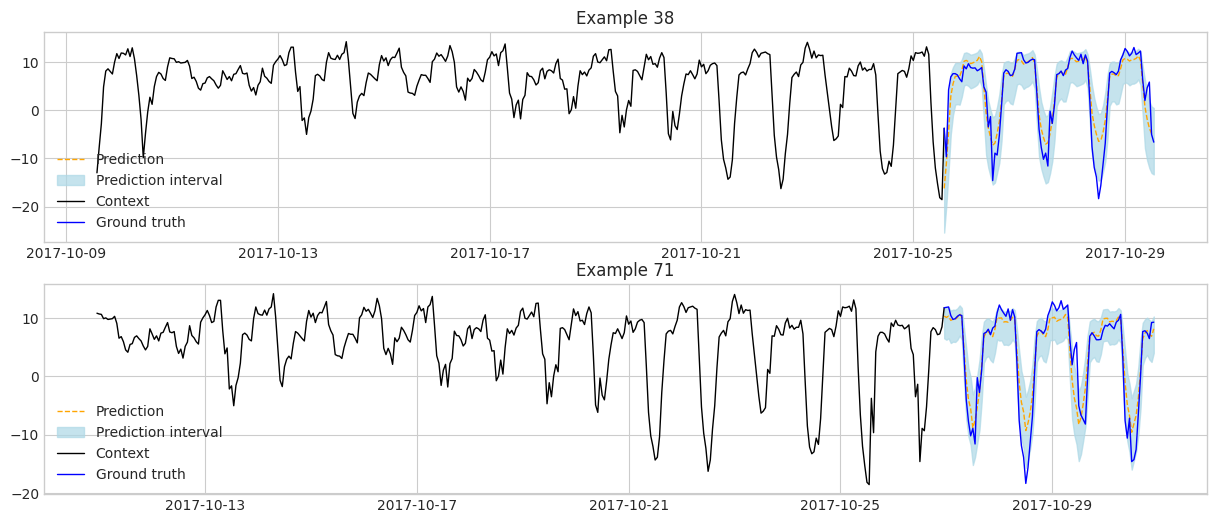

In [12]:
plot_forecast(test_df, forecast_pipe, prediction_length=PREDICTION_LENGTH)

## Forecast for any context length and any prediction length

In [13]:
CONTEXT_LENGTH = 75
PREDICTION_LENGTH = 11

In [14]:
train_df, valid_df, test_df = load_ett_data(context_length=CONTEXT_LENGTH, prediction_length=PREDICTION_LENGTH)

In [15]:
model = get_model(
    MODEL_PATH, context_length=CONTEXT_LENGTH, prediction_length=PREDICTION_LENGTH, freq="H", use_lite=False
)

INFO:p-529606:t-22446896296640:get_model.py:get_model:Loading model from: ibm-research/ttm-r3
INFO:p-529606:t-22446896296640:get_model.py:get_model:Model path type is 4
INFO:p-529606:t-22446896296640:get_model.py:get_model:Loading model from: ibm-granite/granite-timeseries-ttm-r2
INFO:p-529606:t-22446896296640:get_model.py:get_model:Model path type is 2
INFO:p-529606:t-22446896296640:get_model.py:get_model:Would load from ibm-granite/granite-timeseries-ttm-r2, revision = 52-16-ft-r2.1.
INFO:p-529606:t-22446896296640:get_model.py:get_model:Attempting model load from ibm-research/ttm-r3, revision = 156-16-dec-52-r3.
INFO:p-529606:t-22446896296640:get_model.py:get_model:Model loaded successfully from ibm-research/ttm-r3, revision = 156-16-dec-52-r3.
INFO:p-529606:t-22446896296640:get_model.py:get_model:[TTM] context_length = 156, prediction_length = 16


In [16]:
all_data = test_df.iloc[: CONTEXT_LENGTH + PREDICTION_LENGTH + 100]  # take a smaller portion of the data

In [17]:
pipe = TimeSeriesForecastingPipeline(
    model=model,
    id_columns=[],
    timestamp_column=TIMESTAMP_COLUMN,
    target_columns=TARGET_COLUMNS,
    context_length=model.config.context_length,
    prediction_length=PREDICTION_LENGTH,
    batch_size=BATCH_SIZE,
    impute_method=None,
    device=DEVICE,
    quantile_levels=[0.1, 0.5, 0.9],
)

forecast_pipe = pipe(all_data)

Device set to use cuda
INFO:p-529606:t-22446896296640:time_series_forecasting_pipeline.py:preprocess:Preprocessing with: {'prediction_length': 11, 'context_length': 156, 'frequency_token': None, 'id_columns': [], 'timestamp_column': 'date', 'target_columns': ['HUFL'], 'impute_method': None}


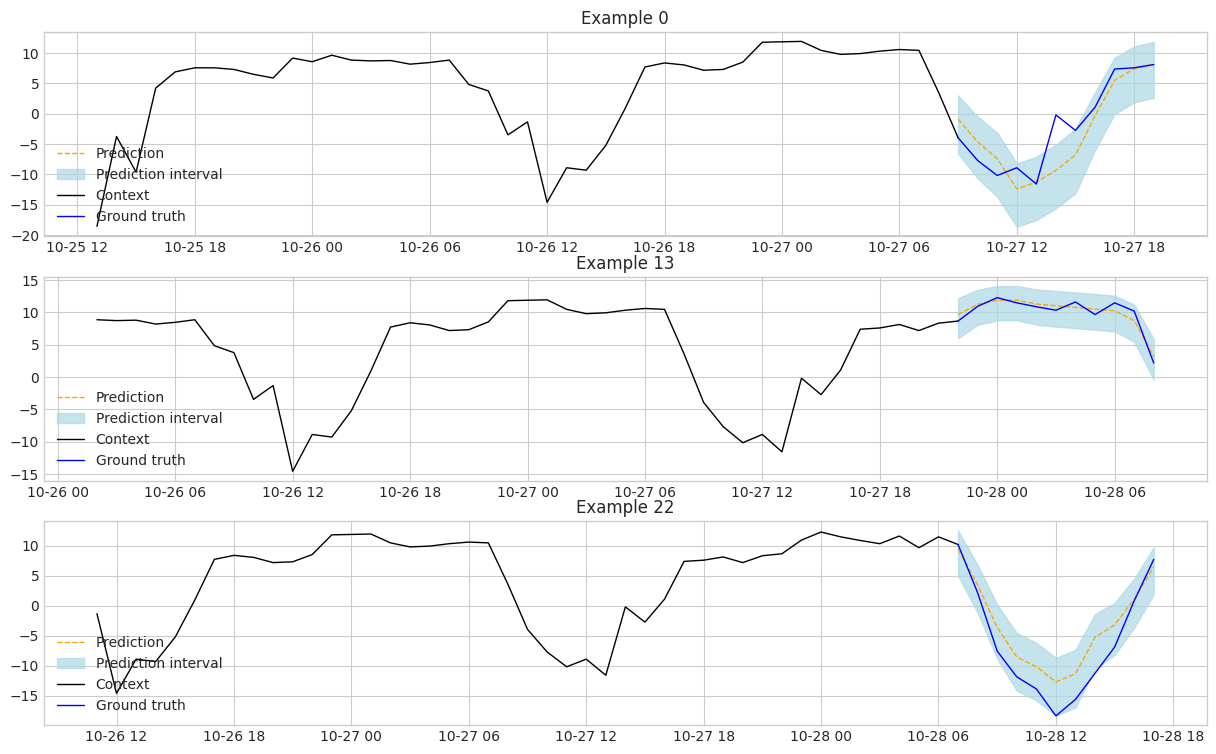

In [18]:
plot_forecast(test_df, forecast_pipe, prediction_length=PREDICTION_LENGTH, indices=[0, 13, 22])

## Links
* Library: [Granite TSFM on Github](https://github.com/ibm-granite/granite-tsfm)
* Model: [TTM-R3 on HuggingFace](https://huggingface.co/ibm-research/ttm-r3)
* Dataset: [Electrical Transformer Dataset](https://github.com/zhouhaoyi/ETDataset)